# **UCI-HAR - Resnet + Contrastive (PyTorch)**

1D ResNet 백본(Backbone)에 지도 학습 기반의 대조 학습(Supervised Contrastive) 메커니즘을 결합

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
# GPU 가속 공식 설정 (Colab 환경 대응)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data load

In [3]:
TRAIN = "train/"
TEST = "test/"

# 구글 드라이브 연동 경로 유지
DATASET_PATH = "/content/drive/MyDrive/AI_Study/UCI_HAR_Dataset/"

In [4]:
# UCI HAR 데이터셋 상수 설정
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [5]:
# 1. X 데이터 로드 함수
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')
                row_clean = row_clean.strip()
                serie = row_clean.split(' ')
                serie_array = np.array(serie, dtype=np.float32)
                series_list.append(serie_array)

        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)

    # 파이토치:   (1, 0, 2) -> (샘플 수, 특성 수, 타임스텝 수)
    return np.transpose(X_signals, (1, 0, 2))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("=== X Data Shape (PyTorch Style) ===")
print("X_train shape (Batch, Channels, Timesteps):", X_train.shape) # (7352, 9, 128)
print("X_test shape (Batch, Channels, Timesteps):", X_test.shape)   # (2947, 9, 128)

=== X Data Shape (PyTorch Style) ===
X_train shape (Batch, Channels, Timesteps): (7352, 9, 128)
X_test shape (Batch, Channels, Timesteps): (2947, 9, 128)


In [7]:
# 2. y 데이터 로드 함수 (정수형 레이블 그대로 유지)
def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    # 파이토치 CrossEntropyLoss는 target으로 Long(int64) 타입을 요구하므로 np.int64로 설정
    return np.array(labels, dtype=np.int64) - 1


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("=== y Data Shape ===")
print("y_train shape (정수 인덱스):", y_train.shape) # (7352,)
print("y_test shape (정수 인덱스):", y_test.shape)   # (2947,)
print("y_train 앞 5개 샘플:", y_train[:5])

=== y Data Shape ===
y_train shape (정수 인덱스): (7352,)
y_test shape (정수 인덱스): (2947,)
y_train 앞 5개 샘플: [4 4 4 4 4]


# Model building

Residual Block (잔차 블록) 정의

In [8]:
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock1D, self).__init__()

        # 첫 번째 Conv Layer
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()

        # 두 번째 Conv Layer
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)

        # Shortcut (지름길) 정의: 입력과 출력의 차원(채널 수 또는 시계열 길이)이 다를 때 맞춰주는 역할
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        # 원래 입력 가중치 저장 (Skip Connection용)
        residual = self.shortcut(x)

        # Main 경로 연산
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # 지름길과 메인 경로 더하기 (Residual Connection)
        out += residual
        out = self.relu(out)

        return out

ResNet + Contrastive Head Model Building

In [10]:
class ResNetContrastive(nn.Module):
    def __init__(self, input_channels=9, num_classes=6, contrast_dim=128):
        super(ResNetContrastive, self).__init__()

        # 2-1. 초기 특징 추출 단계 (Stem Stage)
        self.in_channels = 64
        self.prep_block = nn.Sequential(
            nn.Conv1d(in_channels=input_channels, out_channels=64, kernel_size=7, stride=1, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        # 2-2. ResNet 가중치 층 (Backbone)
        self.layer1 = self._make_layer(out_channels=64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(out_channels=128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(out_channels=256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(out_channels=512, num_blocks=2, stride=2)

        # 2-3. [Contrastive Head] 대조 학습용 네트워크
        # 잠재공간(512차원)을 대조 학습에 적합한 하위 차원(예: 128차원)으로 매핑
        self.contrast_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, contrast_dim)
        )

        # 2-4. [Classification Head]
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(ResidualBlock1D(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # 1. 1D ResNet 백본 통과 -> 특징 추출
        x = self.prep_block(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # 2. Global Average Pooling -> 잠재 벡터 표현 생성 (Shape: [Batch, 512])
        latent_features = F.adaptive_avg_pool1d(x, 1).view(x.size(0), -1)

        # 3. 각 헤드로 분기 연산
        logits = self.fc(latent_features)                         # 분류 결과 ([Batch, num_classes])
        contrast_embeddings = self.contrast_head(latent_features) # 대조 학습용 임베딩 ([Batch, contrast_dim])

        # 대조 학습 성능 향상을 위해 임베딩 벡터를 L2 정규화(Normalization)하여 반환
        contrast_embeddings = F.normalize(contrast_embeddings, p=2, dim=1)

        # 🌟 학습 단계에서 Loss를 동시에 계산할 수 있도록 두 개를 함께 반환
        return logits, contrast_embeddings

모델 생성 및 구조 확인

In [11]:
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 1. 모델 객체 선언
    model = ResNetContrastive(input_channels=9, num_classes=6, contrast_dim=128).to(device)
    print(model)

    # 2. 규격에 맞는 더미 데이터 입력 (Batch=16, Channel=9, Seq_len=128)
    dummy_x = torch.randn(16, 9, 128).to(device)

    # 3. 순전파 실행
    logits, contrast_feats = model(dummy_x)

    print("\n" + "="*50)
    print(f"입력 데이터 형태      : {dummy_x.shape}")              # torch.Size([16, 9, 128])
    print(f"출력 1. 분류값(Logits) 형태: {logits.shape}")          # torch.Size([16, 6])
    print(f"출력 2. 대조 임베딩 형태   : {contrast_feats.shape}")  # torch.Size([16, 128])
    print("="*50)

ResNetContrastive(
  (prep_block): Sequential(
    (0): Conv1d(9, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=

# Loss

지도 대조 학습 손실 함수 (Supervised Contrastive Loss) 정의

In [12]:
class SupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super(SupervisedContrastiveLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        # features shape: [Batch, contrast_dim] -> L2 정규화가 완료된 상태여야 함
        # labels shape: [Batch] 또는 [Batch, num_classes] (원-핫 인코딩 적용)

        # 원-핫 인코딩인 경우 1차원 정수형 라벨로 변환
        if len(labels.shape) > 1 and labels.shape[1] > 1:
            labels = torch.argmax(labels, dim=1)

        device = features.device
        batch_size = features.shape[0]

        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)

        # 자기 자신과의 유사도는 제외하기 위한 마스크 처리
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask

        # 코사인 유사도 계산 (정규화가 되어 있으므로 단순 행렬 곱)
        similarity_matrix = torch.matmul(features, features.T) / self.temperature

        # 수치적 안정을 위해 행별 최댓값을 빼줌 (Log-Sum-Exp 스킬이라고 함 ..)
        logits_max, _ = torch.max(similarity_matrix, dim=1, keepdim=True)
        logits = similarity_matrix - logits_max.detach()

        # 분모 계산: exp(유사도)의 합
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-6)

        # 각 샘플별 양성 쌍(Positive Pairs)의 개수로 나누어 평균 손실 계산
        mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-6)
        loss = -mean_log_prob_pos.mean()
        return loss

손실함수 및 옵티마이저 정의

In [27]:
criterion_ce = nn.CrossEntropyLoss()                              # 1) 분류용 CrossEntropy Loss
criterion_contrast = SupervisedContrastiveLoss(temperature=0.12)  # 2) 대조 학습용 손실 함수

# 가중치 결합 계수 (Total_Loss = Loss_CE + alpha * Loss_Contrast)
# 대조 학습의 영향력을 조절하는 하이퍼파라미터 (보통 0.1 ~ 1.0 사이에서 최적 값을 찾음.)
loss_alpha = 0.2

# 대조 학습용 Projection Head와 분류 레이어 전체를 학습하기 위해 model.parameters() 지정
optimizer = optim.Adam(model.parameters(), lr=0.001)

ReduceLROnPlateau 스케줄러 정의

In [30]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',          # 두 Loss가 더해진 'total_val_loss' 최소화를 목표로 설정
    factor=0.2,
    patience=8,
    min_lr=0.00001,
)

# Callbacks

- 대조 학습이 융합된 모델은 단일 성능 지표보다 val_loss(CE + Contrast)의 추이를 보거나
- 분류 정확도(val_acc) 기준을 그대로 유지하는 것이 좋다고 함.
- 여기서는 분류 성능 기준을 유지.



In [31]:
import copy

early_stopping_patience = 25
patience_counter = 0

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

checkpoint_path = "UCI_HAR_ResNet_Contrastive_best.pt"

# Model train

In [32]:
import time
from torch.utils.data import TensorDataset, random_split

# --- 1. Dataset 및 DataLoader 준비 (Keras의 validation_split=0.2 및 batch_size=16 대응) ---
# 넘파이 배열을 파이토치 텐서로 변환
X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.long)  # 원-핫 인코딩 대신 정수형 레이블 사용

# 전체 데이터셋 생성
full_dataset = TensorDataset(X_tensor, y_tensor)

# 80% 학습, 20% 검증 데이터로 분할
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoader 생성 (batch_size=16)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [33]:
# --- 2. History 저장을 위한 딕셔너리 정의 ---
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

In [34]:
# --- 3. 학습 및 검증 루프 실행 (epochs=150) ---
epochs = 150

for epoch in range(1, epochs + 1):
    start_time = time.time()

    # [Train Phase]
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train_samples = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # 그래디언트 초기화
        optimizer.zero_grad()

        # 순전파 (두 개의 출력을 각각 나누어 받음)
        logits, contrast_embeddings = model(batch_X)

        # 개별 Loss 계산 후 가중치 결합 (Joint Loss)
        loss_ce = criterion_ce(logits, batch_y)
        loss_contrast = criterion_contrast(contrast_embeddings, batch_y)
        loss = loss_ce + (loss_alpha * loss_contrast)

        # 역전파 및 가중치 업데이트 (Backward)
        loss.backward()

        # 🛠️ 추가: 기울기 폭발(Gradient Explosion) 방지 메커니즘 삽입
        # 학습시켜보니 로스 그래프가 너무 튀길래 GPT한테 물어봐서 추가해봄
        # 가중치 업데이트(optimizer.step) 직전에 그래디언트의 최대 크기를 1.0으로 제한
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # 통계 계산 (결합된 loss 기준으로 누적)
        train_loss += loss.item() * batch_X.size(0)

        # 정확도는 분류 헤드(logits) 기준으로 계산
        _, predicted = torch.max(logits, 1)
        train_correct += (predicted == batch_y).sum().item()
        total_train_samples += batch_X.size(0)

    epoch_train_loss = train_loss / total_train_samples
    epoch_train_acc = train_correct / total_train_samples

    # [Validation Phase]
    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val_samples = 0

    with torch.no_grad(): # 검증 시에는 그래디언트 계산 제외 (메모리 절약)
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # 순전파 (검증 단계도 동일하게 분할)
            logits, contrast_embeddings = model(batch_X)

            # 검증 손실 결합
            loss_ce = criterion_ce(logits, batch_y)
            loss_contrast = criterion_contrast(contrast_embeddings, batch_y)
            loss = loss_ce + (loss_alpha * loss_contrast)

            val_loss += loss.item() * batch_X.size(0)

            # 정확도는 분류 헤드(logits) 기준으로 계산
            _, predicted = torch.max(logits, 1)
            val_correct += (predicted == batch_y).sum().item()
            total_val_samples += batch_X.size(0)

    epoch_val_loss = val_loss / total_val_samples
    epoch_val_acc = val_correct / total_val_samples

    # History 기록
    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    # 에포크 결과 출력
    epoch_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}/{epochs} - {epoch_time:.1f}s - loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f} - lr: {current_lr:.6f}")

    # --- 4. Callbacks 수동 연동 단계 ---
    # (1) ReduceLROnPlateau 스케줄러 업데이트 (결합된 val_loss를 기준으로 갱신)
    lr_scheduler.step(epoch_val_loss)

    # (2) ModelCheckpoint & EarlyStopping 체크
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict()) # 최적 가중치 메모리 복사
        torch.save(model.state_dict(), checkpoint_path)    # 파일 저장 (.pt)
        print(f"Epoch {epoch}: val_categorical_accuracy improved to {epoch_val_acc:.5f}, saving model to {checkpoint_path}")
        pvariance_counter = 0
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= early_stopping_patience:
        print(f"Early stopping triggered. Restoring model weights from the end of the best epoch.")
        model.load_state_dict(best_model_wts) # 최적 가중치로 복원
        break

Epoch 1/150 - 6.4s - loss: 0.2028 - accuracy: 0.9876 - val_loss: 0.1755 - val_accuracy: 0.9980 - lr: 0.001000
Epoch 1: val_categorical_accuracy improved to 0.99796, saving model to UCI_HAR_ResNet_Contrastive_best.pt
Epoch 2/150 - 5.2s - loss: 0.1992 - accuracy: 0.9908 - val_loss: 0.1822 - val_accuracy: 0.9946 - lr: 0.001000
Epoch 3/150 - 5.5s - loss: 0.2040 - accuracy: 0.9881 - val_loss: 0.1852 - val_accuracy: 0.9939 - lr: 0.001000
Epoch 4/150 - 5.6s - loss: 0.2019 - accuracy: 0.9895 - val_loss: 0.1825 - val_accuracy: 0.9946 - lr: 0.001000
Epoch 5/150 - 5.1s - loss: 0.1960 - accuracy: 0.9908 - val_loss: 0.1793 - val_accuracy: 0.9939 - lr: 0.001000
Epoch 6/150 - 6.1s - loss: 0.1986 - accuracy: 0.9917 - val_loss: 0.1812 - val_accuracy: 0.9959 - lr: 0.001000
Epoch 7/150 - 5.2s - loss: 0.1981 - accuracy: 0.9917 - val_loss: 0.1767 - val_accuracy: 0.9980 - lr: 0.001000
Epoch 8/150 - 5.8s - loss: 0.1962 - accuracy: 0.9920 - val_loss: 0.1720 - val_accuracy: 0.9986 - lr: 0.001000
Epoch 8: val_c

# Evaluation

Best 기록 확인

In [35]:
# --- 1. 가중치를 불러올 빈 모델 객체 생성 ---
best_model = ResNetContrastive(input_channels=9, num_classes=6).to(device)

# 가중치 파일(.pt) 로드
best_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
print(f"Successfully loaded best model weights from {checkpoint_path}")


# --- 2. 데이터 평가를 위한 수동 함수 정의 (대조 학습 구조 반영) ---
def evaluate_pytorch_contrastive_model(model, X_data, y_data, batch_size=16):
    model.eval() # 평가 모드 활성화 (Dropout, BatchNorm 동결)

    # 평가용 Tensor 구성
    eval_tensor_X = torch.tensor(X_data, dtype=torch.float32)

    # 만약 y_data가 원-핫 인코딩 형태라면 정수형 라벨로 변환
    if len(y_data.shape) > 1 and y_data.shape[1] > 1:
        eval_tensor_y = torch.tensor(np.argmax(y_data, axis=1), dtype=torch.long)
    else:
        eval_tensor_y = torch.tensor(y_data, dtype=torch.long)

    eval_dataset = TensorDataset(eval_tensor_X, eval_tensor_y)
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad(): # 평가 단계이므로 그래디언트 계산 제외
        for batch_X, batch_y in eval_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # 모델 순전파 (두 개의 출력을 각각 나누어 받음)
            logits, contrast_embeddings = model(batch_X)

            # 학습 때와 동일하게 결합된 Total Loss를 계산하여 누적
            loss_ce = criterion_ce(logits, batch_y)
            loss_contrast = criterion_contrast(contrast_embeddings, batch_y)
            loss = loss_ce + (loss_alpha * loss_contrast)

            total_loss += loss.item() * batch_X.size(0)

            # 정확도는 대조 임베딩이 아닌 분류 로짓(logits) 기준으로 판별
            _, predicted = torch.max(logits, 1)
            correct += (predicted == batch_y).sum().item()
            total_samples += batch_X.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = correct / total_samples
    return avg_loss, avg_acc


# --- 3. Training & Test 데이터셋 평가 및 출력 ---
# X_train 전체 데이터에 대해 평가
train_loss, train_acc = evaluate_pytorch_contrastive_model(best_model, X_train, y_train)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

# X_test 데이터셋 평가
test_loss, test_acc = evaluate_pytorch_contrastive_model(best_model, X_test, y_test)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Successfully loaded best model weights from UCI_HAR_ResNet_Contrastive_best.pt
Training accuracy: 99.99%
Training loss: 0.4777
Test accuracy: 96.20%
Test loss: 0.8932


Classification Report

In [36]:
# --- 1. 모델 예측 (Keras의 model.predict 부분) ---
best_model.eval() # 평가 모드 활성화

# 예측용 DataLoader 구성 (X_test 전체를 안정적으로 처리하기 위해 배치 단위 구동)
test_tensor_X = torch.tensor(X_test, dtype=torch.float32)
test_dataset = TensorDataset(test_tensor_X)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

y_pred_list = []

with torch.no_grad():
    for batch_X in test_loader:
        batch_X = batch_X[0].to(device) # TensorDataset은 튜플 형태로 반환하므로 꺼내옴

        # 순전파 시 두 개의 출력을 각각 나누어 받음 (대조 임베딩은 사용하지 않으므로 _ 처리)
        logits, _ = best_model(batch_X)

        # 분류 결과인 logits를 소프트맥스를 통해 확률값으로 변환
        probabilities = F.softmax(logits, dim=1)

        # 가장 높은 확률을 가진 클래스 추출
        _, predicted = torch.max(probabilities, 1)

        # CPU로 넘긴 뒤 리스트에 저장
        y_pred_list.extend(predicted.cpu().numpy())

# 넘파이 배열로 최종 변환
y_pred = np.array(y_pred_list)


# --- 2. 분류 리포트 출력 ---
print("\nClassification Report:")

# 만약 y_test가 원-핫 인코딩 형태라면 정수형 라벨로 변환하여 리포트 출력
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test_true = np.argmax(y_test, axis=1)
else:
    y_test_true = y_test

print(classification_report(y_test_true, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9476    0.9731       496
           1     1.0000    0.9363    0.9671       471
           2     0.9313    1.0000    0.9644       420
           3     0.9308    0.9043    0.9174       491
           4     0.9159    0.9831    0.9483       532
           5     1.0000    1.0000    1.0000       537

    accuracy                         0.9620      2947
   macro avg     0.9630    0.9619    0.9617      2947
weighted avg     0.9635    0.9620    0.9620      2947



Loss / Accuracy 그래프
- 왼쪽 : 세부 Loss 그래프(Total, CE, Contrastive 3가지 추이 시각화)
- 오른쪽 : 기존과 동일한 Accuracy 그래프

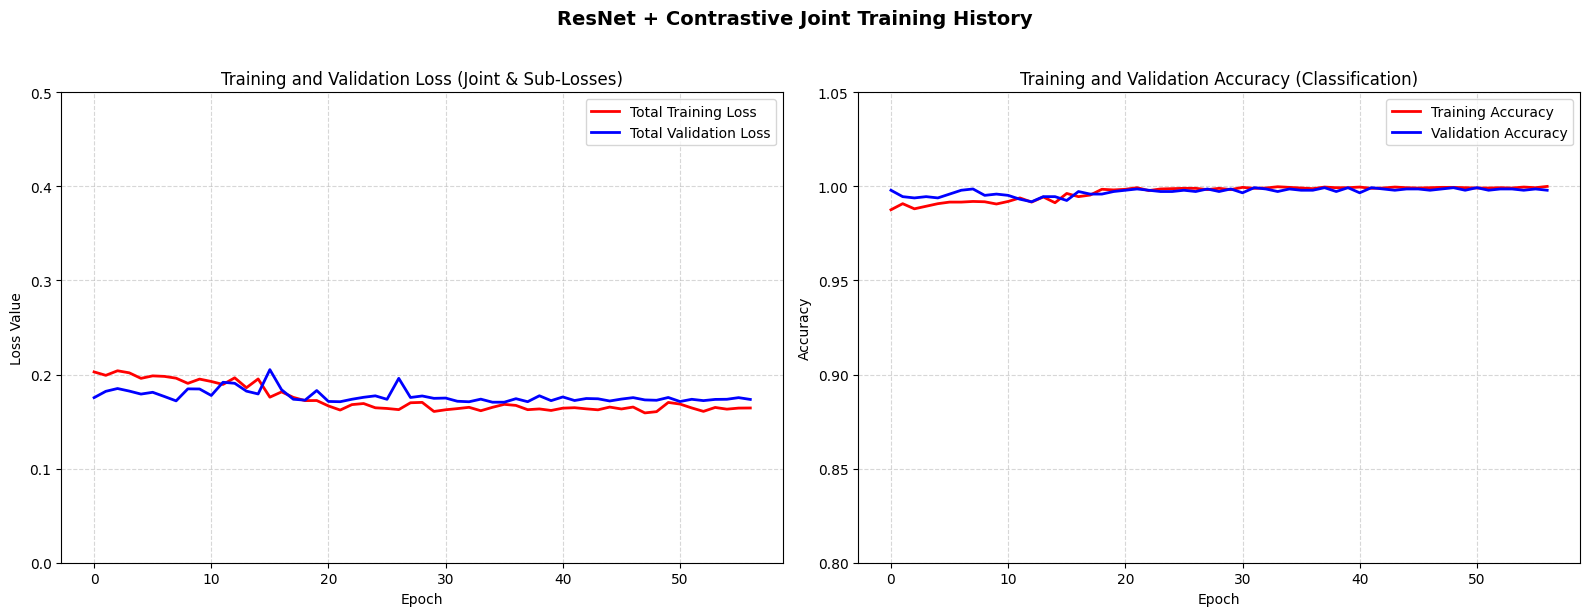

In [40]:
# --- 1. History 딕셔너리에서 학습 기록 데이터 추출 ---
train_loss = history['loss']
val_loss = history['val_loss']
train_accuracy = history['accuracy']
val_accuracy = history['val_accuracy']

# 💡 대조 학습 분석을 위해 세부 Loss 데이터 추출 (학습 루프에서 기록)
# 만약 세부 로깅을 빼놓으셨다면 이 세 줄을 지우고 아래 그래프에서 plot 코드만 주석 처리하셔도 됩니다.
train_loss_ce = history.get('train_loss_ce', None)
train_loss_contrast = history.get('train_loss_contrast', None)


# --- 2. Matplotlib을 이용한 시각화 그래프 그리기 ---
plt.figure(figsize=(16, 6))

# 2-1. Loss 그래프 (왼쪽 - 대조 학습 세부 분석 기능 추가)
plt.subplot(1, 2, 1)
plt.ylim([0.0, 0.5])
# 메인 Total Loss 그래프
plt.plot(train_loss, 'r', linewidth=2, label='Total Training Loss')
plt.plot(val_loss, 'b', linewidth=2, label='Total Validation Loss')

# 🛠️ 추가: 대조 학습과 분류 학습이 각각 잘 수렴하는지 점선으로 시각화
if train_loss_ce is not None and train_loss_contrast is not None:
    plt.plot(train_loss_ce, 'g--', alpha=0.7, label='Train CE Loss (Classification)')
    plt.plot(train_loss_contrast, 'm--', alpha=0.7, label='Train Contrastive Loss')

plt.title('Training and Validation Loss (Joint & Sub-Losses)')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

# 2-2. Accuracy 그래프 (오른쪽)
plt.subplot(1, 2, 2)
plt.ylim([0.8, 1.05]) # 상단 여유를 살짝 주어 가독성 확보
plt.plot(train_accuracy, 'r', linewidth=2, label='Training Accuracy')
plt.plot(val_accuracy, 'b', linewidth=2, label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Classification)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('ResNet + Contrastive Joint Training History', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Embedding Space t-SNE

✅ 추가로 해보면 좋을 것!
- 일반 CrossEntropy로만 학습한 ResNet의 잠재공간 vs 대조 학습으로 학습한 ResNet의 대조 임베딩 공간
  - 좀 더 복잡한 데이터셋에서 대조학습의 효과를 보기 위해 시각화해보면 좋을 것 같음. 꼭 해보기.

입력 공간 형태 (Flattened): (1471, 1152)
대조 공간 임베딩 형태: (1471, 128)
입력 공간 t-SNE 차원 축소 진행 중...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


대조 공간 t-SNE 차원 축소 진행 중...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


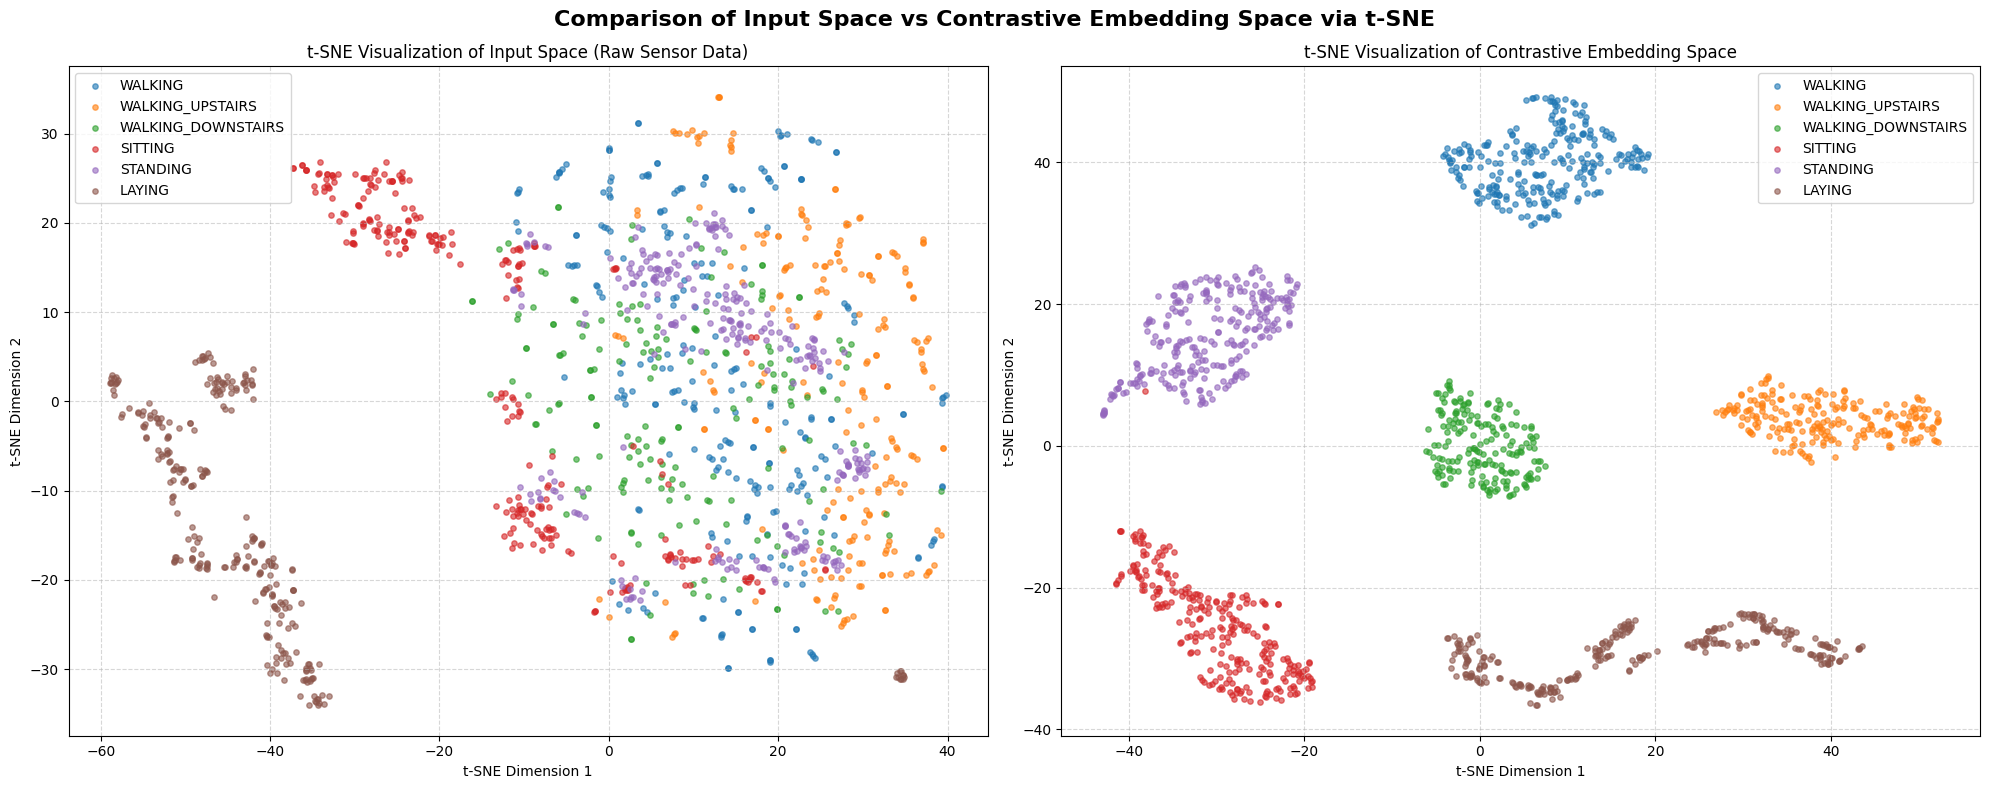

In [42]:
from sklearn.manifold import TSNE

def visualize_dual_tsne_contrastive(model, data_loader, device):
    model.eval()

    input_features = []
    latent_embeddings = []
    labels = []

    # 1. 입력 데이터, 대조 임베딩 벡터 및 라벨 추출
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            # 1-1. 입력 공간 데이터 수집 (Shape: [Batch, Channel * Length])
            inputs_flatten = batch_X.view(batch_X.size(0), -1).cpu().numpy()
            input_features.append(inputs_flatten)

            # 1-2. 대조 공간 임베딩 수집 (Contrastive 모델 구조 반영)
            batch_X = batch_X.to(device)
            _, contrast_embeddings = model(batch_X) # 분류 예측(logits)은 버리고, 대조 임베딩만 수집

            latent_embeddings.append(contrast_embeddings.cpu().numpy())

            # 1-3. 라벨 처리 (원-핫 인코딩 대응 안전장치)
            if len(batch_y.shape) > 1 and batch_y.shape[1] > 1:
                labels.append(torch.argmax(batch_y, dim=1).cpu().numpy())
            else:
                labels.append(batch_y.cpu().numpy())

    # 리스트에 담긴 배치 데이터를 하나로 결합
    input_features = np.concatenate(input_features, axis=0)
    latent_embeddings = np.concatenate(latent_embeddings, axis=0)
    labels = np.concatenate(labels, axis=0)

    print(f"입력 공간 형태 (Flattened): {input_features.shape}")      # (전체 데이터 개수, 9 * 128)
    print(f"대조 공간 임베딩 형태: {latent_embeddings.shape}")        # (전체 데이터 개수, 128)

    # 2. t-SNE를 이용한 차원 축소 (각각 2차원으로 축소)
    print("입력 공간 t-SNE 차원 축소 진행 중...")
    tsne_input = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    tsne_input_results = tsne_input.fit_transform(input_features)

    print("대조 공간 t-SNE 차원 축소 진행 중...")
    tsne_latent = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    tsne_latent_results = tsne_latent.fit_transform(latent_embeddings)

    # 3. Matplotlib 1x2 서브플롯 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # UCI HAR 클래스 네임
    class_names = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
    num_classes = len(class_names)

    # 두 그래프 모두에 클래스별 데이터 플롯
    for i in range(num_classes):
        indices = np.where(labels == i)

        # [왼쪽] 입력 공간 시각화
        ax1.scatter(
            tsne_input_results[indices, 0],
            tsne_input_results[indices, 1],
            label=class_names[i],
            alpha=0.6,
            s=15
        )

        # [오른쪽] 대조 공간 시각화
        ax2.scatter(
            tsne_latent_results[indices, 0],
            tsne_latent_results[indices, 1],
            label=class_names[i],
            alpha=0.6,
            s=15
        )

    # 왼쪽 Plot(입력 공간) 스타일링
    ax1.set_title('t-SNE Visualization of Input Space (Raw Sensor Data)')
    ax1.set_xlabel('t-SNE Dimension 1')
    ax1.set_ylabel('t-SNE Dimension 2')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='best')

    # 오른쪽 Plot(대조 공간) 스타일링
    ax2.set_title('t-SNE Visualization of Contrastive Embedding Space')
    ax2.set_xlabel('t-SNE Dimension 1')
    ax2.set_ylabel('t-SNE Dimension 2')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='best')

    plt.suptitle('Comparison of Input Space vs Contrastive Embedding Space via t-SNE', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- 시각화 함수 호출 ---
visualize_dual_tsne_contrastive(model, val_loader, device)

혼동 행렬 (Confusion Matrix)

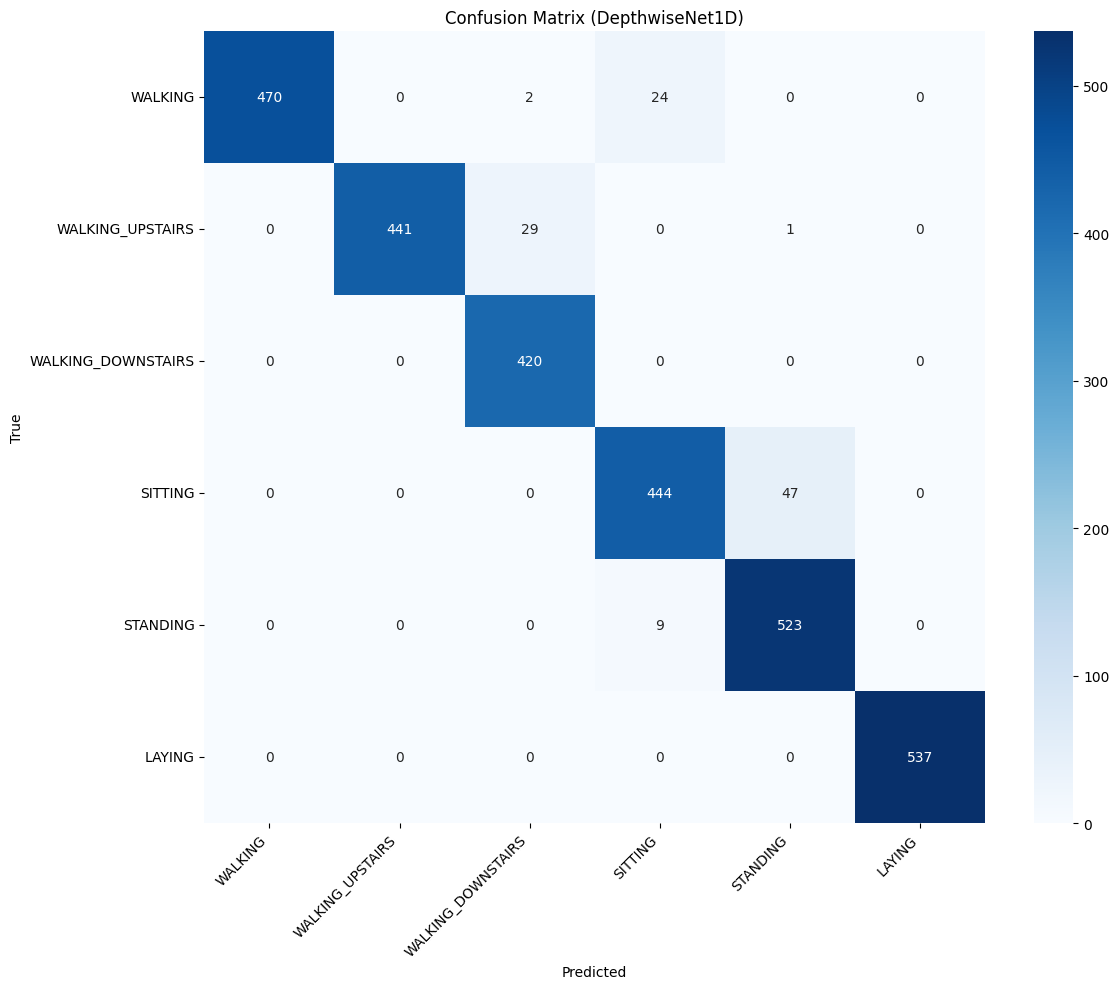

In [41]:
# --- 1. 혼동 행렬(Confusion Matrix) 계산 ---
cm = confusion_matrix(y_test, y_pred)

# --- 2. Seaborn Heatmap을 이용한 시각화 ---
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (DepthwiseNet1D)')

# 클래스 개수에 맞게 축 레이블(WALKING, SITTING 등) 설정
n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()